In [9]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from collections import defaultdict
import numpy as np
import pytz
import re

In [10]:

# Read the list of filenames from the configuration file
with open('file_list.txt', 'r', encoding='utf-8') as config_file:
    file_names = config_file.read().splitlines()

# Regex pattern to match the data format
pattern = r'\[(.*?)\] (.*?): (.*)'

# Initialize an empty list to store parsed data
datalist = []
stream_count = 0
# Iterate over each specified file
for file in file_names:
    full_path = "data\\"+file
    with open(full_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines:
            match = re.match(pattern, line)
            if match:
                date, user, message = match.groups()
                datalist.append([date, user, message,stream_count])
    stream_count = stream_count + 1

# Create a DataFrame from the parsed data
data = pd.DataFrame(datalist, columns=["date", "user", "message","stream"])

In [11]:
data['date'] = pd.to_datetime(data['date'])

In [12]:
def convert_utc_to_cet(df, date_column='date'):
    """
    Convert UTC timestamps to Central European Time (CET/CEST) with proper DST handling
    
    Parameters:
    df (pd.DataFrame): DataFrame containing the date column
    date_column (str): Name of the column containing UTC timestamps
    
    Returns:
    pd.DataFrame: DataFrame with converted timestamps
    """
    # Make a copy to avoid modifying the original
    df = df.copy()
    
    # Ensure timestamps are UTC aware
    if df[date_column].dt.tz is None:
        df[date_column] = df[date_column].dt.tz_localize('UTC')
    elif df[date_column].dt.tz != pytz.UTC:
        df[date_column] = df[date_column].dt.tz_convert('UTC')
    
    # Convert to CET/CEST (Europe/Berlin includes proper DST handling)
    df[date_column] = df[date_column].dt.tz_convert('Europe/Berlin')
    
    return df


In [13]:
data = convert_utc_to_cet(data)

In [30]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for streak messages
# Regex looks for digits followed by "consecutive streams"
streak_pattern = r"(\d+)\s+consecutive\s+streams"
df_streaks = data[data['message'].str.contains(streak_pattern, na=False, case=False)].copy()

# 2. Extract the streak number as an integer
df_streaks['streak_milestone'] = df_streaks['message'].str.extract(streak_pattern)[0].astype(int)

C:\Users\Kardo\AppData\Local\Temp\ipykernel_19280\2619132970.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_streaks = data[data['message'].str.contains(streak_pattern, na=False, case=False)].copy()


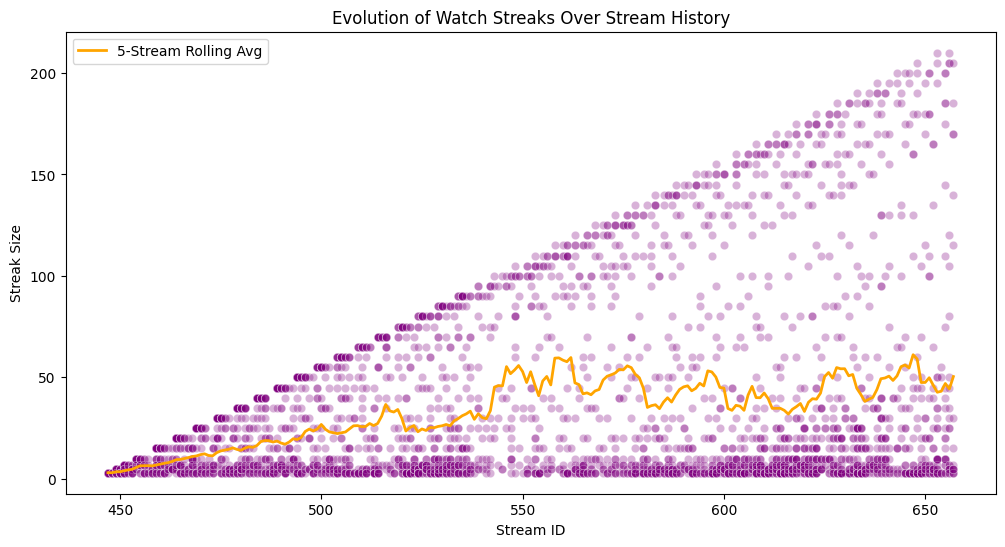

In [32]:
plt.figure(figsize=(12, 6))
# Plot individual streak shares
sns.scatterplot(data=df_streaks, x='stream', y='streak_milestone', alpha=0.3, color='purple')
# Plot a rolling average trend line
rolling_avg = df_streaks.groupby('stream')['streak_milestone'].mean().rolling(window=5, min_periods=1).mean()
plt.plot(rolling_avg.index, rolling_avg.values, color='orange', linewidth=2, label='5-Stream Rolling Avg')

plt.title('Evolution of Watch Streaks Over Stream History')
plt.xlabel('Stream ID')
plt.ylabel('Streak Size')
plt.legend()
plt.show()